# Fase 2: Desarrollo y Entrenamiento del Modelo


Importacion de librerías necesarias y del dataset preparado en la Fase 1.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Cargar dataset preparado
df = pd.read_csv("dataset_preparado.csv", parse_dates=["created_at"])

# Asegurar orden temporal
df = df.sort_values(by=["product_id", "created_at"]).reset_index(drop=True)


print(df.shape)
print("Rango de fechas:", df['created_at'].min(), "a", df['created_at'].max())
df.head()


2025-11-13 15:27:14.308622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-13 15:27:14.323060: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-13 15:27:14.327348: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-13 15:27:14.339759: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 15:27:15.465377: W tensorflow/compiler/tf2

(9520, 14)
Rango de fechas: 2024-07-01 00:00:00 a 2025-10-19 00:00:00


,product_id,created_at,category,quantity_available,quantity_on_hand,quantity_reserved,reorder_point,optimal_stock_level,average_daily_usage,stock_status,anio,mes,dia_semana,fin_de_semana
0,PROD-001,2024-07-01,2,9,10,1,38,60,0.0,3,2024,7,0,False
1,PROD-001,2024-07-02,2,9,10,1,30,40,0.0,3,2024,7,1,False
2,PROD-001,2024-07-03,2,7,10,3,20,27,0.0,3,2024,7,2,False
3,PROD-001,2024-07-04,2,10,10,0,39,58,0.0,3,2024,7,3,False
4,PROD-001,2024-07-05,2,10,10,0,33,71,0.0,3,2024,7,4,False


## Rol: Model Developer

 #### Preparación para secuencias
 - Usaremos una ventana fija `n_steps` para predecir el siguiente día (horizonte = 1).# - Construimos secuencias **por producto** y luego las concatenamos para entrenar un solo modelo global.


In [2]:
# Columnas de entrada
feat_cols = [
    "quantity_on_hand",
    "quantity_reserved",
    "reorder_point",
    "optimal_stock_level",
    "average_daily_usage",
    "stock_status",
    "dia_semana",
    "fin_de_semana",
    "category"   
]

TARGET = "quantity_available"  # variable a predecir
df["fin_de_semana"] = df["fin_de_semana"].astype(int)


 #### Split temporal (Train/Val/Test)
 - Hacemos cortes por **fecha global** para evitar fuga temporal.
 - Train: 70% del rango temporal, Val: 10%, Test: 20%.


In [3]:
min_date = df["created_at"].min()
max_date = df["created_at"].max()
total_days = (max_date - min_date).days

train_end = min_date + timedelta(days=int(total_days * 0.7))
val_end   = min_date + timedelta(days=int(total_days * 0.85))

df_train = df[df["created_at"] <= train_end].copy()
df_val   = df[(df["created_at"] > train_end) & (df["created_at"] <= val_end)].copy()
df_test  = df[df["created_at"] > val_end].copy()

print("Train:", df_train["created_at"].min().date(), "→", df_train["created_at"].max().date(), "| filas:", len(df_train))
print("Val  :", df_val["created_at"].min().date(), "→", df_val["created_at"].max().date(), "| filas:", len(df_val))
print("Test :", df_test["created_at"].min().date(), "→", df_test["created_at"].max().date(), "| filas:", len(df_test))


Train: 2024-07-01 → 2025-05-29 | filas: 6660
Val  : 2025-05-30 → 2025-08-08 | filas: 1420
Test : 2025-08-09 → 2025-10-19 | filas: 1440


#### Escalado con estadísticas del **train**
 Ajustamos el `StandardScaler` en train y transformamos val/test.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_train_s = df_train.copy()
df_val_s   = df_val.copy()
df_test_s  = df_test.copy()

# Fit solo con train
scaler.fit(df_train_s[feat_cols + [TARGET]])

df_train_s[feat_cols + [TARGET]] = scaler.transform(df_train_s[feat_cols + [TARGET]])
df_val_s[feat_cols + [TARGET]]   = scaler.transform(df_val_s[feat_cols + [TARGET]])
df_test_s[feat_cols + [TARGET]]  = scaler.transform(df_test_s[feat_cols + [TARGET]])


#### Función para crear secuencias por producto
 - Devuelve X (n_seq, N_STEPS, n_features), y (n_seq, 1)
 - Conserva timestamps y product_id de la **etiqueta** para evaluación/plots.


In [5]:
N_STEPS = 15

def make_sequences(df_scaled, feat_cols, target_col, n_steps=7):
    X, y = [], []
    for pid, g in df_scaled.groupby("product_id"):
        g = g.sort_values("created_at")
        vals = g[feat_cols + [target_col]].values
        for i in range(n_steps, len(g)):
            X.append(vals[i-n_steps:i, :-1])
            y.append(vals[i, -1])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(df_train_s, feat_cols, TARGET, N_STEPS)
X_val,   y_val   = make_sequences(df_val_s, feat_cols, TARGET, N_STEPS)
X_test,  y_test  = make_sequences(df_test_s, feat_cols, TARGET, N_STEPS)

print("X_train:", X_train.shape, " | X_val:", X_val.shape, " | X_test:", X_test.shape)


X_train: (6360, 15, 9)  | X_val: (1120, 15, 9)  | X_test: (1140, 15, 9)


#### Modelado

In [16]:
def build_model(n_steps, n_features, lstm1=64, lstm2=32, dropout=0.3, lr=0.001):
    model = Sequential([
        LSTM(lstm1, return_sequences=True, input_shape=(n_steps, n_features)),
        Dropout(dropout),

        # LSTM(lstm2, return_sequences=True),
        # Dropout(dropout),

        LSTM(lstm2),
        Dropout(dropout),
        
        Dense(32, activation='relu'),
        Dense(1)

    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model


##  Entrenamiento inicial con MLFLow

In [18]:
import mlflow
import mlflow.keras

params = {
    "n_steps": N_STEPS,
    "batch_size": 128,
    "epochs": 30,
    "learning_rate": 0.01,
    "lstm1": 64,
    "lstm2": 32,
    "dropout": 0.2
}

with mlflow.start_run(run_name="modelo_lstm_base"):
    mlflow.log_params(params)
    
    model = build_model(N_STEPS, len(feat_cols), params["lstm1"], params["lstm2"],
                        params["dropout"], params["learning_rate"])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    y_pred = model.predict(X_test).reshape(-1)
    y_true = y_test.reshape(-1)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    mlflow.log_metrics({"rmse": rmse, "mae": mae})
    mlflow.keras.log_model(model, "modelo_lstm")
    
    print(f" Entrenamiento base completado | RMSE={rmse:.4f}, MAE={mae:.4f}")


/home/karen/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1566 - rmse: 0.3957 - val_loss: 0.1159 - val_rmse: 0.3404 - learning_rate: 0.0100
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0850 - rmse: 0.2916 - val_loss: 0.0926 - val_rmse: 0.3043 - learning_rate: 0.0100
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0785 - rmse: 0.2802 - val_loss: 0.0899 - val_rmse: 0.2999 - learning_rate: 0.0100
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0755 - rmse: 0.2747 - val_loss: 0.0881 - val_rmse: 0.2968 - learning_rate: 0.0100
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0741 - rmse: 0.2722 - val_loss: 0.0993 - val_rmse: 0.3151 - learning_rate: 0.0100
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0728 - rmse: 0.2698 - val_loss: 0.0919 - val_rmse: 0.3031 - learning_rate: 0.0100
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0742 - rmse: 0.2724 - val_loss: 0.0874 - val_rmse: 0.2956 - learning_rate: 0.0100

2025/11/13 15:40:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


 Entrenamiento base completado | RMSE=0.2688, MAE=0.1872


 ## Fine tuning de hiperparámetros con MLflow 


In [ ]:
for lr in [0.001, 0.0005]:
    for drop in [0.2, 0.3]:
        with mlflow.start_run(run_name=f"fine_tuning_lr{lr}_drop{drop}"):
            mlflow.log_params({
                "learning_rate": lr,
                "dropout": drop,
                "epochs": 40,
                "batch_size": 64,
                "lstm1": 64,
                "lstm2": 32
            })
            
            model = build_model(N_STEPS, len(feat_cols),
                                lstm1=64, lstm2=32, dropout=drop, lr=lr)
            
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=40,
                batch_size=64,
                verbose=0
            )
            
            y_pred = model.predict(X_test).reshape(-1)
            y_true = y_test.reshape(-1)
            
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            
            mlflow.log_metrics({"rmse": rmse, "mae": mae})
            mlflow.keras.log_model(model, "modelo_tuned")
            
            print(f"Fine-tuning lr={lr}, drop={drop} | RMSE={rmse:.4f}, MAE={mae:.4f}")

print(" Fine-tuning completado.")


/home/karen/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


2025/11/13 00:44:50 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Fine-tuning lr=0.001, drop=0.2 | RMSE=0.2891, MAE=0.2192


/home/karen/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Fine-tuning lr=0.0005, drop=0.2 | RMSE=0.2754, MAE=0.1999


/home/karen/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


2025/11/13 00:46:09 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Fine-tuning lr=0.0005, drop=0.3 | RMSE=0.2736, MAE=0.1865
 Fine-tuning completado.


#### Entrenamiento con MLflow

In [8]:
model.save("modelo.h5")

 ## 8. Evaluación (MAE y RMSE) y curva de entrenamiento


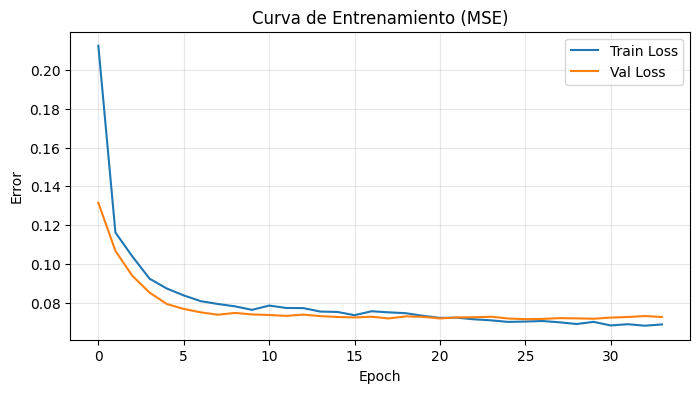

In [9]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Curva de Entrenamiento (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [10]:
# Predicciones
y_pred = model.predict(X_test).reshape(-1)
y_true = y_test.reshape(-1)

# Métricas globales
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f" RMSE global: {rmse:.4f}")
print(f" MAE global: {mae:.4f}")

# RMSE por categoría
for cat in df["category"].unique():
    mask = (df_test["category"] == cat)
    Xc, yc = make_sequences(df_test_s[mask], feat_cols, TARGET, N_STEPS)
    if len(yc) > 0:
        y_pred_c = model.predict(Xc).reshape(-1)
        rmse_c = np.sqrt(mean_squared_error(yc, y_pred_c))
        print(f"{cat}: RMSE = {rmse_c:.3f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
 RMSE global: 0.2631
 MAE global: 0.1650
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2: RMSE = 0.052
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
0: RMSE = 0.336
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1: RMSE = 0.278
